# Data Collection and Exploration

## Objectives

The objectives of this notebook are to:

- Load and inspect the Heritage Housing dataset.
- Understand the structure and content of the data.
- Identify numerical and categorical variables.
- Detect missing values and duplicate records.
- Explore the distribution of the target variable, `SalePrice`.
- Investigate relationships between property characteristics and sale price.
- Identify features that may be useful for machine learning.

---

## Inputs

- Heritage Housing dataset: `house_prices_records.csv`
- Business requirements and hypotheses defined in Notebook 1

---

## Outputs

This notebook produces:

- An initial understanding of the dataset.
- A summary of data quality issues.
- Identification of numerical and categorical features.
- Visualisations of the target variable and important predictors.
- Evidence used to guide data cleaning, feature engineering and modelling.

## Load the Dataset

The dataset is loaded from the project input directory using Pandas. The same source dataset will be used throughout the data preparation and modelling workflow.

In [17]:
import pandas as pd

df = pd.read_csv("../inputs/datasets/house_prices_records.csv")

## Initial Dataset Inspection

### Dataset Preview

The first rows are displayed to review the structure of the dataset and understand how the property characteristics and target variable are represented.

In [18]:
df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,...,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,...,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000


### Dataset Shape

The dataset shape is checked to identify the number of property records and variables available for analysis.

In [19]:
df.shape

(1460, 24)

The dataset contains **1,460 property records and 24 columns**, including the target variable `SalePrice`.

### Data Types and Missing Values

The dataset information is reviewed to identify column data types, non-null values and potential missing-data issues. This helps determine which variables will require numerical or categorical preprocessing.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   1stFlrSF       1460 non-null   int64  
 1   2ndFlrSF       1374 non-null   float64
 2   BedroomAbvGr   1361 non-null   float64
 3   BsmtExposure   1422 non-null   object 
 4   BsmtFinSF1     1460 non-null   int64  
 5   BsmtFinType1   1315 non-null   object 
 6   BsmtUnfSF      1460 non-null   int64  
 7   EnclosedPorch  136 non-null    float64
 8   GarageArea     1460 non-null   int64  
 9   GarageFinish   1225 non-null   object 
 10  GarageYrBlt    1379 non-null   float64
 11  GrLivArea      1460 non-null   int64  
 12  KitchenQual    1460 non-null   object 
 13  LotArea        1460 non-null   int64  
 14  LotFrontage    1201 non-null   float64
 15  MasVnrArea     1452 non-null   float64
 16  OpenPorchSF    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  OverallQ

### Descriptive Statistics

Summary statistics are generated for the numerical variables to understand their ranges, averages and variation. This can also highlight unusual values or potential outliers that may require further investigation.

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0
2ndFlrSF,1374.0,348.524017,438.865586,0.0,0.00,0.0,728.00,2065.0
BedroomAbvGr,1361.0,2.869214,0.820115,0.0,2.00,3.0,3.00,8.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0
EnclosedPorch,136.0,25.330882,66.684115,0.0,0.00,0.0,0.00,286.0
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0
GarageYrBlt,1379.0,1978.506164,24.689725,1900.0,1961.00,1980.0,2002.00,2010.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0


The numerical variables have very different measurement scales. For example, quality ratings use a small ordinal scale, while areas and sale prices are measured using much larger values. This will be considered during modelling and preprocessing.

### Missing Values

Missing values are identified because incomplete observations may affect visualisation, feature engineering and model training. Only columns containing missing data are displayed.

In [22]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

missing_values

EnclosedPorch    1324
WoodDeckSF       1305
LotFrontage       259
GarageFinish      235
BsmtFinType1      145
BedroomAbvGr       99
2ndFlrSF           86
GarageYrBlt        81
BsmtExposure       38
MasVnrArea          8
dtype: int64

Missing values were identified in several property variables, as shown in the output above. These values will be investigated and handled during the data-cleaning stage.

The target variable, `SalePrice`, contains no missing values. Therefore, every property record has a known sale price and can potentially be used for supervised machine learning after preprocessing.

### Duplicate Records

Duplicate rows are checked because repeated records could bias the exploratory analysis and model training.

In [23]:
duplicate_count = df.duplicated().sum()
duplicate_count

0

No duplicate records were identified in the dataset.

## Feature Types

The dataset contains both numerical and categorical variables. Separating them helps determine which preprocessing methods will be required later.

Numerical variables may be used directly or transformed, while categorical variables may require encoding before model training.

In [24]:
numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical columns: {len(numerical_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

Numerical columns: 20
Categorical columns: 4


In [25]:
print("Numerical variables:")
print(numerical_columns)

print("\nCategorical variables:")
print(categorical_columns)

Numerical variables:
['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'BsmtFinSF1', 'BsmtUnfSF', 'EnclosedPorch', 'GarageArea', 'GarageYrBlt', 'GrLivArea', 'LotArea', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'OverallCond', 'OverallQual', 'TotalBsmtSF', 'WoodDeckSF', 'YearBuilt', 'YearRemodAdd', 'SalePrice']

Categorical variables:
['BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'KitchenQual']


## Initial Data Quality Findings

The initial inspection produced the following findings:

- The dataset contains 1,460 property records and 24 columns.
- It includes both numerical and categorical features.
- Several columns contain missing values and will require cleaning.
- The target variable, `SalePrice`, contains no missing values.
- No duplicate rows were identified.
- The dataset is suitable for further exploratory analysis and supervised regression modelling after preprocessing.

## Target Variable Analysis

### Distribution of Sale Price

`SalePrice` is the target variable that the machine learning model will predict. Its distribution is examined to understand the range of property prices, identify skewness and detect potentially influential high-value observations.

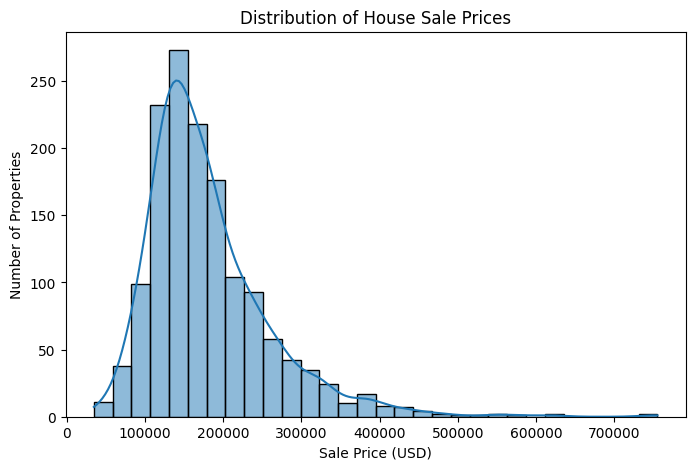

In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Create the output directory if it doesn't exist
Path("outputs/plots").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="SalePrice",
    bins=30,
    kde=True
)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price (USD)")
plt.ylabel("Number of Properties")

plt.savefig("outputs/plots/sale_price_distribution.png")

plt.show()

The distribution of `SalePrice` is positively skewed. Most properties were sold within the lower-to-middle price ranges, while a smaller number of expensive houses create a long right tail.

This suggests that the target variable is not normally distributed and that high-value properties may have a strong influence on model errors. A logarithmic transformation of `SalePrice` could be investigated during modelling, although it should only be used if it improves performance and interpretation.

## Correlation Analysis

### Correlation Heatmap

A correlation heatmap is used to examine linear relationships between numerical variables. This helps identify variables that move together and highlights potential predictors of `SalePrice`.

Correlation does not prove causation, but it is useful for guiding further analysis and feature selection.

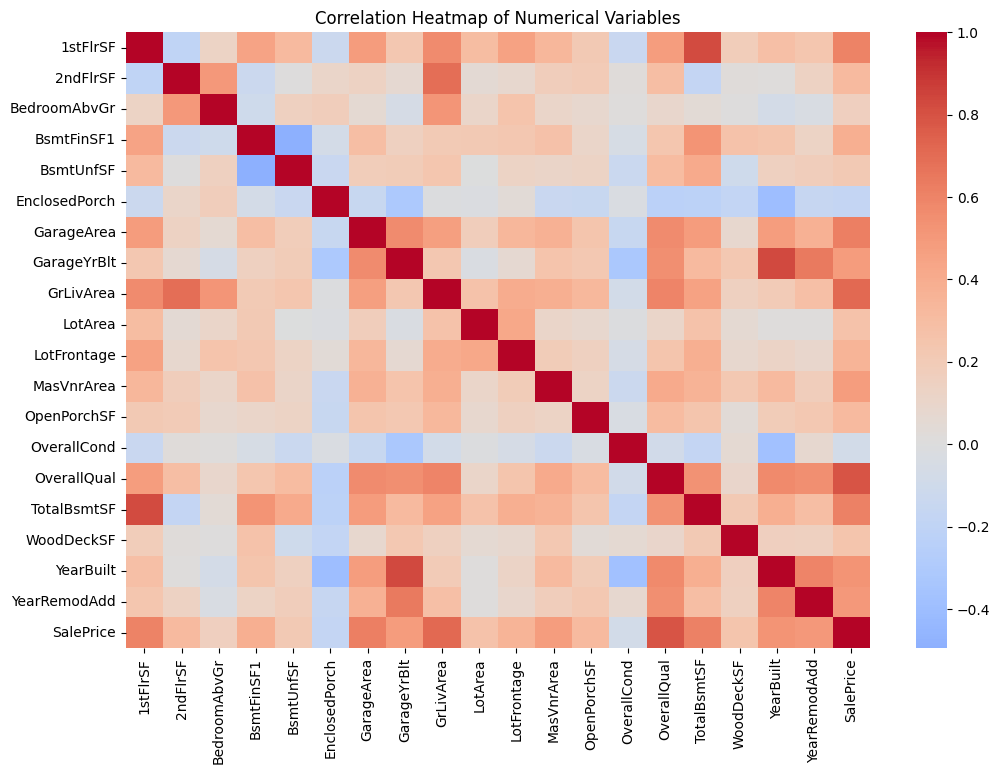

In [27]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Correlation with SalePrice

The correlation between every numerical variable and `SalePrice` is calculated and ranked.

Variables with stronger positive or negative correlations may contain useful predictive information.

In [28]:
sale_price_correlation = (
    numeric_df.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

sale_price_correlation

OverallQual      0.790982
GrLivArea        0.708624
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
BsmtFinSF1       0.386420
LotFrontage      0.351799
2ndFlrSF         0.322335
OpenPorchSF      0.315856
LotArea          0.263843
WoodDeckSF       0.252027
BsmtUnfSF        0.214479
BedroomAbvGr     0.161901
OverallCond     -0.077856
EnclosedPorch   -0.176458
Name: SalePrice, dtype: float64

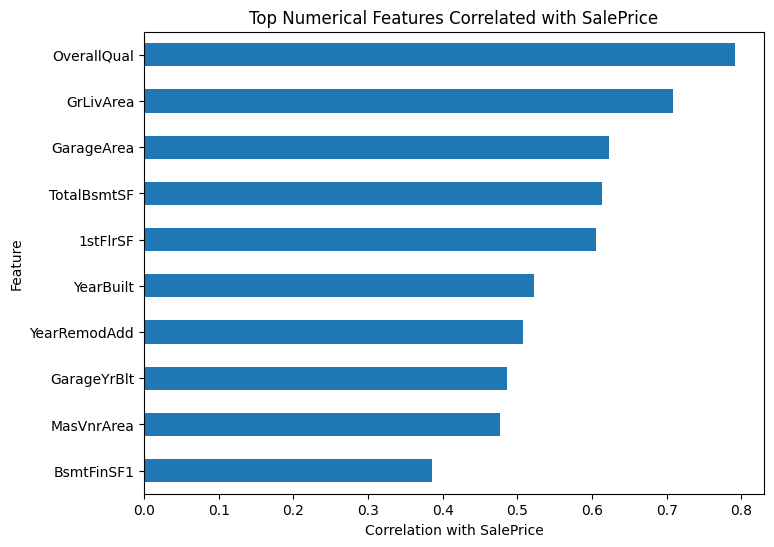

In [37]:
top_correlations = sale_price_correlation.head(10)

plt.figure(figsize=(8, 6))

top_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Top Numerical Features Correlated with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")

plt.savefig("outputs/plots/top_correlated_features.png")

plt.show()

The strongest positive correlations with `SalePrice` were observed for:

- `OverallQual`
- `GrLivArea`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`

These variables describe overall property quality and usable space, suggesting that larger and higher-quality homes generally achieve higher sale prices.

These findings support the business requirement to identify the property attributes most strongly associated with sale price. However, correlation alone is not sufficient to confirm that a variable will improve prediction performance, so the features will also be evaluated during modelling.

## Investigation of Key Features

### Ground Living Area and Sale Price

`GrLivArea` represents the above-ground living area of a property.

It was selected for closer investigation because it has one of the strongest positive correlations with `SalePrice`.

This visualisation is used to test the hypothesis that larger living areas are associated with higher sale prices.

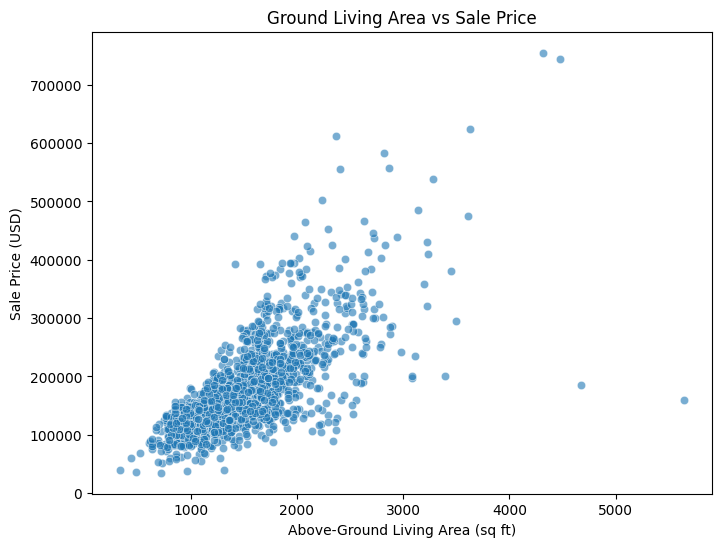

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.6
)

plt.title("Ground Living Area vs Sale Price")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price (USD)")

plt.show()

The scatter plot shows a clear positive relationship between above-ground living area and sale price.

In general, houses with larger living areas sell for higher prices.

A small number of observations appear far from the main pattern and may represent unusual or high-value properties. These observations should be considered during model evaluation.

**Hypothesis outcome:** Supported.

### Overall Quality and Sale Price

`OverallQual` is an ordinal rating of the overall material and finish quality of a property.

It is investigated because it has the strongest positive correlation with `SalePrice`.

A boxplot is appropriate because it compares the distribution of sale prices across each quality rating.

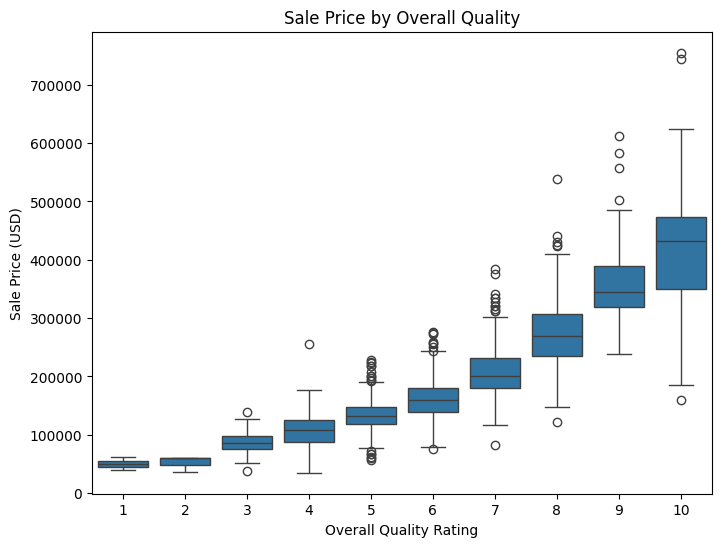

In [31]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price (USD)")

plt.show()

The median sale price increases substantially as the overall quality rating rises.

Higher-quality properties also show a wider price range, particularly among the highest ratings.

This provides strong evidence that overall quality is an important factor in determining property value.

**Hypothesis outcome:** Supported.

### Year Built and Sale Price

`YearBuilt` is examined to test whether newer houses generally achieve higher sale prices.

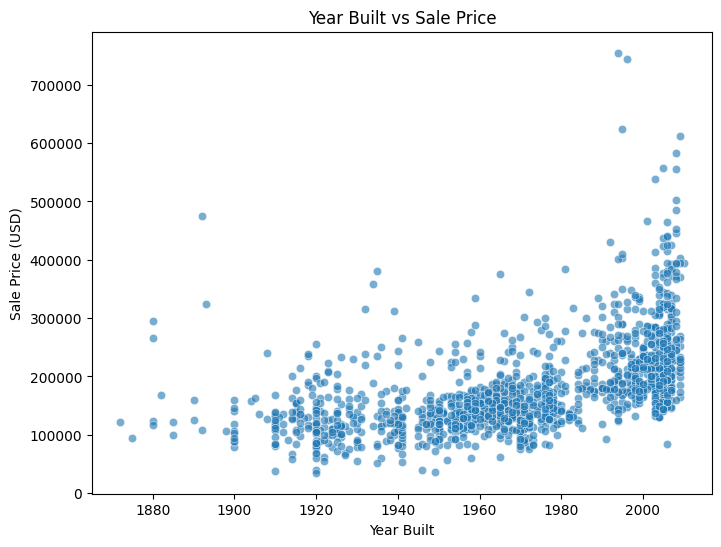

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="YearBuilt",
    y="SalePrice",
    alpha=0.6
)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price (USD)")

plt.show()

The visualisation indicates a general tendency for newer houses to achieve higher sale prices.

However, the relationship is less consistent than those observed for overall quality and living area.

Older properties can still achieve high prices when they possess other desirable characteristics, such as strong quality ratings, renovations or larger living areas.

**Hypothesis outcome:** Partially supported.

### Garage Area and Sale Price

`GarageArea` represents the total size of the property's garage.

It is examined to investigate whether larger garages are associated with higher house sale prices.

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GarageArea",
    y="SalePrice",
    alpha=0.6
)

plt.title("Garage Area vs Sale Price")
plt.xlabel("Garage Area (sq ft)")
plt.ylabel("Sale Price (USD)")

plt.show()

The plot shows a positive relationship between garage area and sale price.

Properties with larger garages generally achieve higher sale prices, although the relationship contains considerable variation.

This suggests that garage space contributes to property value but should be considered together with overall quality, living area and other property features.

**Hypothesis outcome:** Supported.

## Exploration Summary

The exploratory analysis identified several important findings:

- `SalePrice` has a positively skewed distribution.
- `OverallQual` has the strongest observed numerical correlation with sale price.
- Above-ground living area is strongly and positively related to sale price.
- Garage area and basement area also appear to be useful predictors.
- Newer houses generally sell for more, although the relationship is influenced by other property characteristics.
- Missing values are present in several variables and must be handled before modelling.
- No duplicate rows were identified.

These findings support the client's first business requirement by identifying and visualising the property characteristics most strongly related to sale price.

The next notebook will focus on cleaning the dataset and preparing it for feature engineering and machine learning.